### 1. DP1 CDFS complementary photometry diagnostics: vertical-line origin and optical-coverage checks

This notebook is a complementary diagnostic to the main DP1 CDFS photometry notebook. The main notebook contains the final cleaned photometric comparisons, residual plots, colour-colour diagrams, and bright-end residual tests. This notebook documents the lower-level checks that motivated the final per-band quality logic.

The starting point was the appearance of artificial vertical structures in some colour-colour diagrams, especially diagrams involving optical colours such as `g-i`. These structures were not interpreted as astrophysical sequences. They were traced to unreliable forced measurements in individual optical bands: repeated or suspicious optical magnitudes, high aperture-flux flag fractions, and cases where the optical measurement was effectively not usable.

After that first catalogue-level diagnosis, I checked a more specific question. Some sources are bright and well measured in the near-infrared `K` band, but have very faint, flagged, or unreliable forced photometry in an optical band such as `g`. This does not necessarily mean that the `K` source is wrong or mismatched. In a forced-photometry catalogue, a source position can be measured in every band even when a particular band has no valid local image coverage, bad mask planes, interpolation, or missing data.

The purpose of this notebook is therefore to connect the colour-colour vertical-line problem to the underlying image-level cause. It checks whether bright `K` / problematic-`g` sources are true cross-band mismatches, or whether they are real `K` detections whose optical forced measurements fall on invalid or low-coverage `g` pixels.

The notebook combines two checks: first, a reduced-catalogue check to identify bright `K` sources with problematic `g` measurements; second, a patch-level Butler/image check to inspect the same source class directly on the `K` and `g` coadds, including mask-plane coverage.

The main conclusion tested here is that quality cuts must be applied per band. A bad or missing optical forced measurement should not automatically remove a real near-infrared source from all diagnostics. Instead, each colour or residual plot should require good measurements only in the bands used by that diagnostic.

### 2. Imports, paths, and settings

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.table import Table
from IPython.display import display

try:
    import lsst.daf.butler as dafButler
    import lsst.geom as geom
    import lsst.afw.image as afwImage
    HAS_LSST = True
except Exception as e:
    HAS_LSST = False
    print("LSST stack is not available in this kernel.")
    print("Catalogue-level sections can still run, but Butler/coadd sections need an LSST environment.")
    print(type(e).__name__, e)

# ------------------------------------------------------------------
# Input paths
# ------------------------------------------------------------------

DATA_DIR = Path("../data")

DP1_PATH = DATA_DIR / "full_reduced_cat_DP1_20260408.fits"

# HPC Butler run used for the by-eye and mask-plane diagnostics.
BUTLER_LOC = "../../../dmu4/dmu4_DP1/dmu4_DP1_ECDFS/data"
COLL_MEAS_FORCED   = "u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z"
COLL_CALEXP_VIRCAM = "u/ir-sare1/DRP/videoCoaddDetect"

# Optical ComCam coadds are stored as FITS files in this run.
COMCAM_COADD_DIR = Path(BUTLER_LOC) / "ComCam/deepCoadd_results/deepCoadd_calexp"

SKYMAP = "lsst_cells_v1"

# Test patch used in the by-eye diagnostic.
# These values can be changed to inspect another patch.
TRACT = 4848
PATCH = 83

# Example suspicious source used for quick cutout checks.
TARGET_RA_DEG  = 52.393752
TARGET_DEC_DEG = -28.403291

# Photometric thresholds.
MAGERR_5SIG = 2.5 / np.log(10) / 5.0
K_BRIGHT_LIM = 18.0
G_FAINT_LIM = 24.0

# Aperture used in the forced-photometry diagnostic.
AP_SUFFIX = "base_CircularApertureFlux_6_0"

# Output directory for figures and small diagnostic tables.
OUTDIR = Path("data/plots_photometry")
OUTDIR.mkdir(parents=True, exist_ok=True)

SAVE_FIGURES = True

print("DP1 catalogue:", DP1_PATH)
print("Butler repo  :", BUTLER_LOC)
print("VIRCAM coadd collection:", COLL_CALEXP_VIRCAM)
print("Forced-photometry collection:", COLL_MEAS_FORCED)
print("ComCam coadd directory:", COMCAM_COADD_DIR)
print("Output directory:", OUTDIR)

DP1 catalogue: ../data/full_reduced_cat_DP1_20260408.fits
Butler repo  : ../../../dmu4/dmu4_DP1/dmu4_DP1_ECDFS/data
VIRCAM coadd collection: u/ir-sare1/DRP/videoCoaddDetect
Forced-photometry collection: u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
ComCam coadd directory: ../../../dmu4/dmu4_DP1/dmu4_DP1_ECDFS/data/ComCam/deepCoadd_results/deepCoadd_calexp
Output directory: data/plots_photometry


### 3. Load the reduced DP1 catalogue

The reduced catalogue is used for the first, catalogue-level check. This gives a quick overview of how many bright `K` sources have problematic `g` forced photometry before moving to the image-level inspection.

In [2]:
dp1c = Table.read(DP1_PATH)

print("Loaded:", DP1_PATH)
print("N rows:", len(dp1c))
print("N columns:", len(dp1c.colnames))

print("\nFirst 40 columns:")
for col in dp1c.colnames[:40]:
    print(" ", col)

Loaded: ../data/full_reduced_cat_DP1_20260408.fits
N rows: 1380173
N columns: 87

First 40 columns:
  id
  VIRCAM_Z_m_base_ClassificationExtendedness_value
  VIRCAM_Z_m_base_ClassificationExtendedness_flag
  VIRCAM_Z_m_base_CircularApertureFlux_6_0_magErr
  VIRCAM_Z_m_base_CircularApertureFlux_6_0_mag
  VIRCAM_Z_m_base_CircularApertureFlux_6_0_fluxErr
  VIRCAM_Z_m_base_CircularApertureFlux_6_0_flux
  VIRCAM_Z_m_base_CircularApertureFlux_6_0_flag
  VIRCAM_Y_m_base_ClassificationExtendedness_value
  VIRCAM_Y_m_base_ClassificationExtendedness_flag
  VIRCAM_Y_m_base_CircularApertureFlux_6_0_magErr
  VIRCAM_Y_m_base_CircularApertureFlux_6_0_mag
  VIRCAM_Y_m_base_CircularApertureFlux_6_0_fluxErr
  VIRCAM_Y_m_base_CircularApertureFlux_6_0_flux
  VIRCAM_Y_m_base_CircularApertureFlux_6_0_flag
  VIRCAM_K_m_merge_peak_sky
  VIRCAM_K_m_detect_isTractInner
  VIRCAM_K_m_detect_isPrimary
  VIRCAM_K_m_detect_isPatchInner
  VIRCAM_K_m_deblend_nChild
  VIRCAM_K_m_coord_ra
  VIRCAM_K_m_coord_dec
  VIRCAM

### 4. Reduced-catalogue helper functions

In [3]:
BAND_PREFIX = {
    "u":  "ComCam_u_m",
    "g":  "ComCam_g_m",
    "r":  "ComCam_r_m",
    "i":  "ComCam_i_m",
    "z":  "ComCam_z_m",
    "y":  "ComCam_y_m",
    "Y":  "VIRCAM_Y_m",
    "J":  "VIRCAM_J_m",
    "H":  "VIRCAM_H_m",
    "K":  "VIRCAM_K_m",
}


def table_has_col(tab, col):
    return col in tab.colnames


def get_col(tab, col, dtype=float):
    if not table_has_col(tab, col):
        raise KeyError(f"Missing required column: {col}")
    return np.asarray(tab[col], dtype=dtype)


def band_columns(band):
    prefix = BAND_PREFIX[band]
    base = f"{prefix}_{AP_SUFFIX}"
    return {
        "mag": f"{base}_mag",
        "err": f"{base}_magErr",
        "flag": f"{base}_flag",
        "ra": f"{prefix}_coord_ra",
        "dec": f"{prefix}_coord_dec",
    }


def band_mag(band):
    return get_col(dp1c, band_columns(band)["mag"], float)


def band_err(band):
    return get_col(dp1c, band_columns(band)["err"], float)


def band_flag(band):
    col = band_columns(band)["flag"]
    if not table_has_col(dp1c, col):
        return np.zeros(len(dp1c), dtype=bool)
    return get_col(dp1c, col, bool)


def finite_error_mask(band, err_lim=MAGERR_5SIG):
    mag = band_mag(band)
    err = band_err(band)
    return (
        np.isfinite(mag)
        & np.isfinite(err)
        & (err > 0)
        & (err < err_lim)
    )


def qstats(arr, mask):
    arr = np.asarray(arr, float)
    vals = arr[mask & np.isfinite(arr)]
    if vals.size == 0:
        return np.array([np.nan] * 5)
    return np.nanpercentile(vals, [5, 16, 50, 84, 95])


def savefig(filename, dpi=300):
    if SAVE_FIGURES:
        plt.savefig(OUTDIR / filename, dpi=dpi, bbox_inches="tight")

### 5. Catalogue-level link between vertical-line artefacts and band-specific failures

The vertical structures in the main colour-colour plots were caused by a small number of unreliable optical measurements entering colours such as `g-i`. This cell gives a compact catalogue-level summary of the same issue.

The important point is not only that some optical measurements are bad, but that they are bad in a band-specific way. A source can be a good `K` detection while its `g` measurement is flagged, missing, or too faint to be usable. These objects motivate the image-level checks in the rest of the notebook.

In [4]:
K_mag = band_mag("K")
K_err = band_err("K")
K_flag = band_flag("K")

g_mag = band_mag("g")
g_err = band_err("g")
g_flag = band_flag("g")

K_good = finite_error_mask("K") & (~K_flag)
g_good = finite_error_mask("g") & (~g_flag)

K_bright_catalogue = K_good & (K_mag < K_BRIGHT_LIM)

problematic_g_catalogue = (
    (~g_good)
    | (~np.isfinite(g_mag))
    | (~np.isfinite(g_err))
    | g_flag
    | (g_mag > G_FAINT_LIM)
)

bright_K_problematic_g_catalogue = K_bright_catalogue & problematic_g_catalogue
bright_K_good_g_catalogue = K_bright_catalogue & g_good & (g_mag < 22.0)

print("Catalogue-level summary")
print("  N K good:", int(K_good.sum()))
print(f"  N K bright, K < {K_BRIGHT_LIM}:", int(K_bright_catalogue.sum()))
print("  N bright K with problematic g:", int(bright_K_problematic_g_catalogue.sum()))
print("  N bright K with good g control:", int(bright_K_good_g_catalogue.sum()))

print("\nProblematic-g reasons among K-bright sources:")
print("  non-finite g mag/error:", int((K_bright_catalogue & ((~np.isfinite(g_mag)) | (~np.isfinite(g_err)))).sum()))
print("  g aperture flag:", int((K_bright_catalogue & g_flag).sum()))
print(f"  g > {G_FAINT_LIM}:", int((K_bright_catalogue & np.isfinite(g_mag) & (g_mag > G_FAINT_LIM)).sum()))
print("  high g magErr:", int((K_bright_catalogue & np.isfinite(g_err) & (g_err >= MAGERR_5SIG)).sum()))

summary_rows = np.where(bright_K_problematic_g_catalogue)[0]
diagnostic_table = pd.DataFrame({
    "row": summary_rows,
    "K_mag": K_mag[summary_rows],
    "K_magerr": K_err[summary_rows],
    "K_flag": K_flag[summary_rows],
    "g_mag": g_mag[summary_rows],
    "g_magerr": g_err[summary_rows],
    "g_flag": g_flag[summary_rows],
})

csv_path = OUTDIR / "catalogue_bright_K_problematic_g_candidates.csv"
diagnostic_table.sort_values("K_mag").to_csv(csv_path, index=False)

print("\nSaved:", csv_path)
display(diagnostic_table.sort_values("K_mag").head(20))

Catalogue-level summary
  N K good: 351845
  N K bright, K < 18.0: 1856
  N bright K with problematic g: 1079
  N bright K with good g control: 776

Problematic-g reasons among K-bright sources:
  non-finite g mag/error: 293
  g aperture flag: 1076
  g > 24.0: 638
  high g magErr: 94

Saved: data/plots_photometry/catalogue_bright_K_problematic_g_candidates.csv


,row,K_mag,K_magerr,K_flag,g_mag,g_magerr,g_flag
316,431009,14.709170,0.000012,False,16.417044,0.000910,True
617,976645,14.915010,0.000017,False,15.907210,0.001046,True
921,1271874,14.925794,0.000012,False,25.609257,0.054434,True
941,1278828,14.925843,0.000012,False,25.609257,0.054434,True
233,325697,14.970228,0.000018,False,14.597159,0.000729,True
927,1273247,14.976705,0.000015,False,25.627941,0.055379,True
948,1280981,14.977838,0.000015,False,25.627941,0.055379,True
353,520577,15.011594,0.000014,False,26.764173,0.106908,True
374,526142,15.011594,0.000014,False,26.764173,0.106908,True
1055,1368353,15.028943,0.000013,False,NaN,NaN,True


### 6. Open the Butler repository and load patch-level products

The following sections use the LSST stack and the HPC Butler run. They load the `K` coadd, the `g` coadd, and the corresponding forced-photometry catalogues for one test patch.

In [5]:
if not HAS_LSST:
    raise RuntimeError("The LSST stack is required for the Butler/coadd sections.")

butler = dafButler.Butler(BUTLER_LOC)

print("Butler opened successfully")
print("Using tract:", TRACT)
print("Using patch:", PATCH)
print("ComCam coadd directory exists:", COMCAM_COADD_DIR.exists())

Butler opened successfully
Using tract: 4848
Using patch: 83
ComCam coadd directory exists: True


### 7. Load K and g coadds and forced catalogues

The `K` coadd is read from the VIRCAM Butler collection. The `g` coadd is read from the fixed ComCam coadd directory. The forced catalogues for both bands are read from the same forced-photometry collection.

In [6]:
def load_vista_coadd_from_butler(band):
    refs = list(
        butler.registry.queryDatasets(
            "deepCoadd_calexp",
            collections=[COLL_CALEXP_VIRCAM],
            where="skymap = SKYMAP AND tract = TRACT AND patch = PATCH AND band = BAND",
            bind={
                "SKYMAP": SKYMAP,
                "TRACT": TRACT,
                "PATCH": PATCH,
                "BAND": band,
            },
        )
    )

    print()
    print(f"VIRCAM {band} coadd from Butler")
    print("dataset_type =", "deepCoadd_calexp")
    print("collection   =", COLL_CALEXP_VIRCAM)
    print("N refs       =", len(refs))

    for ii, ref in enumerate(refs):
        print(ii, ref.dataId, "run =", ref.run)

    if len(refs) == 0:
        raise RuntimeError(f"No VIRCAM {band} deepCoadd_calexp found.")

    ref = refs[-1]
    exp = butler.get(ref)

    print(f"Loaded VIRCAM {band} coadd from run:", ref.run)
    return exp, ref


def find_comcam_coadd_file(band="g"):
    if not COMCAM_COADD_DIR.exists():
        raise RuntimeError(f"ComCam coadd directory does not exist: {COMCAM_COADD_DIR}")

    all_files = (
        list(COMCAM_COADD_DIR.rglob("*.fits"))
        + list(COMCAM_COADD_DIR.rglob("*.fits.fz"))
        + list(COMCAM_COADD_DIR.rglob("*.fz"))
    )

    candidates = []
    for p in all_files:
        s = str(p)
        slow = s.lower()

        has_band = (
            f"/{band}/" in slow
            or f"_{band}_" in slow
            or f"-{band}-" in slow
            or f"band-{band}" in slow
            or f"filter-{band}" in slow
        )
        has_tract = str(TRACT) in s
        has_patch = str(PATCH) in s or f"p{PATCH}" in slow or f"patch{PATCH}" in slow

        if has_band and has_tract and has_patch:
            candidates.append(p)

    print()
    print(f"ComCam {band} coadd FITS search")
    print("directory =", COMCAM_COADD_DIR)
    print("N FITS-like files =", len(all_files))
    print("N candidates =", len(candidates))

    for ii, p in enumerate(candidates[:20]):
        print(ii, p)

    if len(candidates) == 0:
        raise RuntimeError(
            f"No ComCam {band} coadd file found for tract={TRACT}, patch={PATCH}. "
            "Adjust find_comcam_coadd_file() for the local file naming convention."
        )

    candidates = sorted(candidates, key=lambda p: (len(str(p)), str(p)))
    return candidates[0]


def load_forced_catalogue(band):
    refs = list(
        butler.registry.queryDatasets(
            "deepCoadd_forced_src",
            collections=[COLL_MEAS_FORCED],
            where="skymap = SKYMAP AND tract = TRACT AND patch = PATCH AND band = BAND",
            bind={
                "SKYMAP": SKYMAP,
                "TRACT": TRACT,
                "PATCH": PATCH,
                "BAND": band,
            },
        )
    )

    print()
    print(f"Forced catalogue for band {band}")
    print("dataset_type =", "deepCoadd_forced_src")
    print("collection   =", COLL_MEAS_FORCED)
    print("N refs       =", len(refs))

    for ii, ref in enumerate(refs):
        print(ii, ref.dataId, "run =", ref.run)

    if len(refs) == 0:
        raise RuntimeError(f"No deepCoadd_forced_src catalogue found for band={band}")

    ref = refs[-1]
    cat = butler.get(ref)

    print(f"Loaded {band} forced catalogue from run:", ref.run)
    print(f"N rows in {band} catalogue:", len(cat))

    return cat, ref


K_exp, K_ref = load_vista_coadd_from_butler("K")

g_file = find_comcam_coadd_file("g")
g_exp = afwImage.ExposureF(str(g_file))

K_cat, K_cat_ref = load_forced_catalogue("K")
g_cat, g_cat_ref = load_forced_catalogue("g")

print()
print("Loaded ComCam g coadd from file:")
print(g_file)

print()
print("K image bbox:", K_exp.getBBox())
print("g image bbox:", g_exp.getBBox())


VIRCAM K coadd from Butler
dataset_type = deepCoadd_calexp
collection   = u/ir-sare1/DRP/videoCoaddDetect
N refs       = 1
0 {band: 'K', skymap: 'lsst_cells_v1', tract: 4848, patch: 83} run = u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z
Loaded VIRCAM K coadd from run: u/ir-sare1/DRP/videoCoaddDetect/20260405T092826Z

ComCam g coadd FITS search
directory = ../../../dmu4/dmu4_DP1/dmu4_DP1_ECDFS/data/ComCam/deepCoadd_results/deepCoadd_calexp
N FITS-like files = 485
N candidates = 1
0 ../../../dmu4/dmu4_DP1/dmu4_DP1_ECDFS/data/ComCam/deepCoadd_results/deepCoadd_calexp/4848/83/g/deepCoadd_calexp_4848_83_g_lsst_cells_v1_ComCam_deepCoadd_results.fits

Forced catalogue for band K
dataset_type = deepCoadd_forced_src
collection   = u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
N refs       = 1
0 {band: 'K', skymap: 'lsst_cells_v1', tract: 4848, patch: 83} run = u/ir-sare1/DRP/videoMultiVisit/20260406T094204Z
Loaded K forced catalogue from run: u/ir-sare1/DRP/videoMultiVisit/20260406T09420

### 8. Convert forced fluxes to approximate coadd-calibrated magnitudes

For this by-eye diagnostic, a single coadd-level conversion using `PhotoCalib.getInstFluxAtZeroMagnitude()` is sufficient. The purpose is to select bright `K` sources and problematic `g` measurements, not to perform the final catalogue calibration.

In [7]:
def require_field(cat, name, label):
    names = set(cat.schema.getNames())
    if name not in names:
        raise KeyError(f"Missing field {name!r} in {label} catalogue")
    return name


def catalogue_array(cat, field):
    return np.asarray(cat[field])


def mag_from_instflux(exp, flux, flux_err=None):
    flux = np.asarray(flux, float)
    zpf = exp.getPhotoCalib().getInstFluxAtZeroMagnitude()

    mag = np.full(flux.shape, np.nan, dtype=float)
    good = np.isfinite(flux) & (flux > 0) & np.isfinite(zpf) & (zpf > 0)
    mag[good] = -2.5 * np.log10(flux[good] / zpf)

    if flux_err is None:
        return mag

    flux_err = np.asarray(flux_err, float)
    mag_err = np.full(flux.shape, np.nan, dtype=float)
    good_err = good & np.isfinite(flux_err) & (flux_err > 0)
    mag_err[good_err] = 2.5 / np.log(10) * flux_err[good_err] / flux[good_err]

    return mag, mag_err


K_flux_col = require_field(K_cat, f"{AP_SUFFIX}_instFlux", "K")
K_err_col  = require_field(K_cat, f"{AP_SUFFIX}_instFluxErr", "K")
K_flag_col = require_field(K_cat, f"{AP_SUFFIX}_flag", "K")

g_flux_col = require_field(g_cat, f"{AP_SUFFIX}_instFlux", "g")
g_err_col  = require_field(g_cat, f"{AP_SUFFIX}_instFluxErr", "g")
g_flag_col = require_field(g_cat, f"{AP_SUFFIX}_flag", "g")

K_flux = catalogue_array(K_cat, K_flux_col)
K_fluxerr = catalogue_array(K_cat, K_err_col)
K_flag_patch = catalogue_array(K_cat, K_flag_col).astype(bool)

g_flux = catalogue_array(g_cat, g_flux_col)
g_fluxerr = catalogue_array(g_cat, g_err_col)
g_flag_patch = catalogue_array(g_cat, g_flag_col).astype(bool)

K_mag_patch, K_magerr_patch = mag_from_instflux(K_exp, K_flux, K_fluxerr)
g_mag_patch, g_magerr_patch = mag_from_instflux(g_exp, g_flux, g_fluxerr)

print("K mag finite:", np.isfinite(K_mag_patch).sum(), "/", len(K_mag_patch))
print("g mag finite:", np.isfinite(g_mag_patch).sum(), "/", len(g_mag_patch))
print("K mag range:", np.nanpercentile(K_mag_patch, [1, 5, 50, 95, 99]))
print("g mag range:", np.nanpercentile(g_mag_patch, [1, 5, 50, 95, 99]))

K mag finite: 11387 / 12458
g mag finite: 12143 / 12458
K mag range: [18.23204416 21.52497488 24.9268145  27.70601196 32.02103423]
g mag range: [21.69976348 24.22707543 25.62875237 26.46622057 27.73448259]


### 9. Match K and g forced catalogues by source ID

The forced catalogues should normally contain the same object IDs across bands. Matching by source ID allows the `g` measurements to be placed onto the `K` catalogue row system.

In [8]:
def get_id_array(cat):
    names = set(cat.schema.getNames())
    if "id" in names:
        return np.asarray(cat["id"])
    return np.arange(len(cat), dtype=np.int64)


K_id = get_id_array(K_cat)
g_id = get_id_array(g_cat)

sort_g = np.argsort(g_id)
g_id_sorted = g_id[sort_g]

pos = np.searchsorted(g_id_sorted, K_id)
safe_pos = np.minimum(pos, len(g_id_sorted) - 1)

matched_by_id = (
    (pos < len(g_id_sorted))
    & (g_id_sorted[safe_pos] == K_id)
)

g_row = np.full(len(K_id), -1, dtype=int)
g_row[matched_by_id] = sort_g[pos[matched_by_id]]

print("N K catalogue rows:", len(K_id))
print("N g catalogue rows:", len(g_id))
print("N matched by id:", int(matched_by_id.sum()))
print("matched fraction relative to K:", matched_by_id.sum() / len(K_id))

g_mag_on_K = np.full(len(K_id), np.nan)
g_magerr_on_K = np.full(len(K_id), np.nan)
g_flag_on_K = np.ones(len(K_id), dtype=bool)
g_flux_on_K = np.full(len(K_id), np.nan)
g_fluxerr_on_K = np.full(len(K_id), np.nan)

g_mag_on_K[matched_by_id] = g_mag_patch[g_row[matched_by_id]]
g_magerr_on_K[matched_by_id] = g_magerr_patch[g_row[matched_by_id]]
g_flag_on_K[matched_by_id] = g_flag_patch[g_row[matched_by_id]]
g_flux_on_K[matched_by_id] = g_flux[g_row[matched_by_id]]
g_fluxerr_on_K[matched_by_id] = g_fluxerr[g_row[matched_by_id]]

N K catalogue rows: 12458
N g catalogue rows: 12458
N matched by id: 12458
matched fraction relative to K: 1.0


### 10. Coordinates and pixel positions

Positions are taken from the `K` forced catalogue and projected onto both the `K` and `g` coadd images. This checks the same sky positions in both bands.

In [9]:
def get_coord_from_cat(cat):
    names = set(cat.schema.getNames())
    if "coord_ra" in names and "coord_dec" in names:
        ra = np.asarray(cat["coord_ra"], float)
        dec = np.asarray(cat["coord_dec"], float)

        if np.nanmax(np.abs(ra)) > 7:
            ra = np.deg2rad(ra)
        if np.nanmax(np.abs(dec)) > 7:
            dec = np.deg2rad(dec)

        return ra, dec

    ra = np.empty(len(cat), dtype=float)
    dec = np.empty(len(cat), dtype=float)

    for ii, rec in enumerate(cat):
        sp = rec.getCoord()
        ra[ii] = sp.getRa().asRadians()
        dec[ii] = sp.getDec().asRadians()

    return ra, dec


def sky_to_display_pixels(exp, ra_rad, dec_rad):
    wcs = exp.getWcs()
    bbox = exp.getBBox()

    x = np.full(len(ra_rad), np.nan)
    y = np.full(len(ra_rad), np.nan)

    for ii, (ra, dec) in enumerate(zip(ra_rad, dec_rad)):
        if not (np.isfinite(ra) and np.isfinite(dec)):
            continue

        sp = geom.SpherePoint(ra * geom.radians, dec * geom.radians)
        pix = wcs.skyToPixel(sp)

        x[ii] = pix.getX() - bbox.getMinX()
        y[ii] = pix.getY() - bbox.getMinY()

    return x, y


ra_K, dec_K = get_coord_from_cat(K_cat)
ra_deg_patch = np.rad2deg(ra_K)
dec_deg_patch = np.rad2deg(dec_K)

xK, yK = sky_to_display_pixels(K_exp, ra_K, dec_K)
xg, yg = sky_to_display_pixels(g_exp, ra_K, dec_K)

print("RA range:", np.nanmin(ra_deg_patch), np.nanmax(ra_deg_patch))
print("Dec range:", np.nanmin(dec_deg_patch), np.nanmax(dec_deg_patch))
print("Finite K pixels:", np.isfinite(xK).sum())
print("Finite g pixels:", np.isfinite(xg).sum())

RA range: 52.32670823138499 52.541003232341154
Dec range: -28.518783543212244 -28.330371889401484
Finite K pixels: 12458
Finite g pixels: 12458


### 11. Define bright-K suspicious and control samples

Suspicious sources are bright in `K` but have problematic `g` forced photometry. Control sources are bright in `K` and have normal-looking `g` measurements.

In [10]:
K_good_basic_patch = (
    np.isfinite(K_mag_patch)
    & np.isfinite(K_magerr_patch)
    & (K_magerr_patch > 0)
    & (K_magerr_patch < MAGERR_5SIG)
    & (~K_flag_patch)
)

g_good_basic_patch = (
    matched_by_id
    & np.isfinite(g_mag_on_K)
    & np.isfinite(g_magerr_on_K)
    & (g_magerr_on_K > 0)
    & (g_magerr_on_K < MAGERR_5SIG)
    & (~g_flag_on_K)
)

K_bright_patch = K_good_basic_patch & (K_mag_patch < K_BRIGHT_LIM)

suspicious = (
    K_bright_patch
    & (
        (~matched_by_id)
        | (~np.isfinite(g_mag_on_K))
        | (~np.isfinite(g_magerr_on_K))
        | g_flag_on_K
        | (g_mag_on_K > G_FAINT_LIM)
    )
)

control = (
    K_bright_patch
    & g_good_basic_patch
    & (g_mag_on_K < 22.0)
)

print("N K good basic:", int(K_good_basic_patch.sum()))
print(f"N K bright, K < {K_BRIGHT_LIM}:", int(K_bright_patch.sum()))
print("N suspicious K-bright:", int(suspicious.sum()))
print("N control K-bright:", int(control.sum()))

print("\nSuspicious reasons:")
print("  no matched g row:       ", int((K_bright_patch & (~matched_by_id)).sum()))
print("  non-finite g mag/error: ", int((K_bright_patch & matched_by_id & ((~np.isfinite(g_mag_on_K)) | (~np.isfinite(g_magerr_on_K)))).sum()))
print("  g aperture flag:        ", int((K_bright_patch & g_flag_on_K).sum()))
print(f"  g > {G_FAINT_LIM}:              ", int((K_bright_patch & (g_mag_on_K > G_FAINT_LIM)).sum()))

src = pd.DataFrame({
    "k_row": np.arange(len(K_id)),
    "source_id": K_id,
    "g_row": g_row,
    "matched_g": matched_by_id,
    "ra_deg": ra_deg_patch,
    "dec_deg": dec_deg_patch,
    "K_mag": K_mag_patch,
    "K_magerr": K_magerr_patch,
    "K_flag": K_flag_patch,
    "g_mag": g_mag_on_K,
    "g_magerr": g_magerr_on_K,
    "g_flag": g_flag_on_K,
    "xK": xK,
    "yK": yK,
    "xg": xg,
    "yg": yg,
    "K_bright": K_bright_patch,
    "suspicious": suspicious,
    "control": control,
})

patch_csv = OUTDIR / f"tract{TRACT}_patch{PATCH}_Kg_forced_by_eye_source_table.csv"
src.to_csv(patch_csv, index=False)

print("\nSaved:", patch_csv)
display(src.loc[suspicious].sort_values("K_mag").head(20))

N K good basic: 7418
N K bright, K < 18.0: 65
N suspicious K-bright: 39
N control K-bright: 25

Suspicious reasons:
  no matched g row:        0
  non-finite g mag/error:  0
  g aperture flag:         0
  g > 24.0:               39

Saved: data/plots_photometry/tract4848_patch83_Kg_forced_by_eye_source_table.csv


,k_row,source_id,g_row,matched_g,ra_deg,dec_deg,K_mag,K_magerr,K_flag,g_mag,g_magerr,g_flag,xK,yK,xg,yg,K_bright,suspicious,control
1932,1932,33320906038184255,1932,True,52.363800,-28.480242,14.926010,0.000012,False,25.608929,0.054352,False,2808.772352,700.649614,2808.772352,700.649614,True,True,False
8886,8886,33320906038195840,8886,True,52.363800,-28.480242,14.926060,0.000012,False,25.608929,0.054352,False,2808.772067,700.650096,2808.772067,700.650096,True,True,False
3305,3305,33320906038185716,3305,True,52.372428,-28.376819,14.976705,0.000015,False,25.627651,0.055314,False,2668.746029,2562.218194,2668.746029,2562.218194,True,True,False
11039,11039,33320906038197993,11039,True,52.372450,-28.376827,14.979684,0.000015,False,25.627694,0.055312,False,2668.405372,2562.065998,2668.405372,2562.065998,True,True,False
1247,1247,33320906038183540,1247,True,52.357186,-28.515856,15.098285,0.000015,False,26.466142,0.119664,False,2914.552737,59.732437,2914.552737,59.732437,True,True,False
7710,7710,33320906038194664,7710,True,52.357186,-28.515856,15.098286,0.000015,False,26.466142,0.119664,False,2914.552743,59.732431,2914.552743,59.732431,True,True,False
10461,10461,33320906038197415,10461,True,52.393943,-28.403441,15.527712,0.000037,False,25.627756,0.055333,False,2328.980506,2082.296862,2328.980506,2082.296862,True,True,False
10462,10462,33320906038197416,10462,True,52.394231,-28.403495,15.610642,0.000038,False,25.627558,0.055267,False,2324.426838,2081.326544,2324.426838,2081.326544,True,True,False
10459,10459,33320906038197413,10459,True,52.394612,-28.403316,15.690716,0.000044,False,25.627537,0.055256,False,2318.389665,2084.525808,2318.389665,2084.525808,True,True,False
11040,11040,33320906038197994,11040,True,52.372388,-28.375620,15.748839,0.000027,False,25.627632,0.055302,False,2669.342754,2583.805920,2669.342754,2583.805920,True,True,False


### 12. Whole-patch overlays

The same `K`-selected forced-source positions are plotted on both the `K` and `g` coadd images. This gives a quick visual check of whether suspicious sources are spatially clustered, located near image edges, or associated with poor optical coverage.

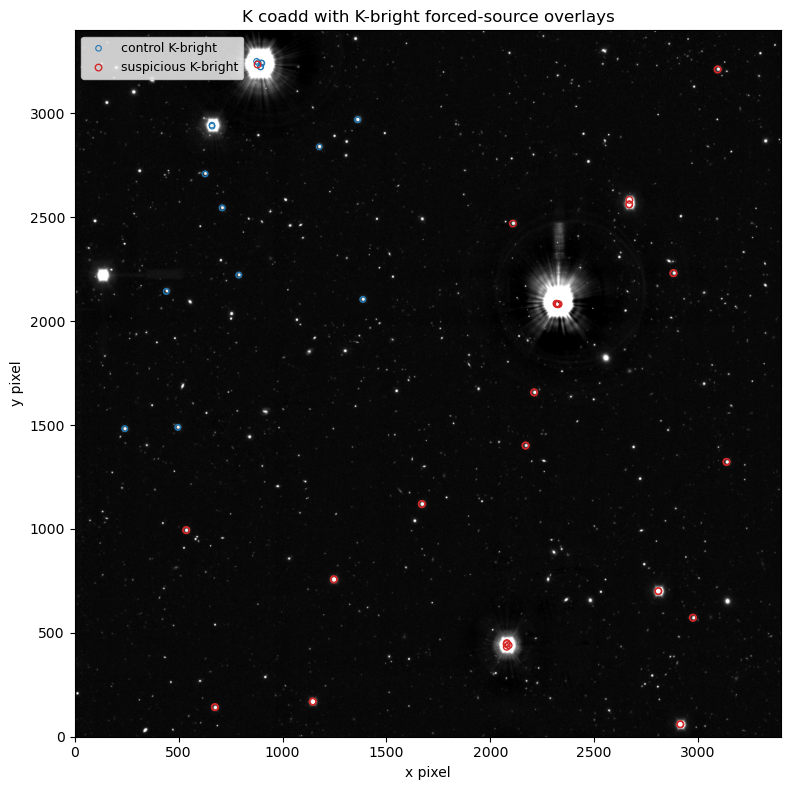

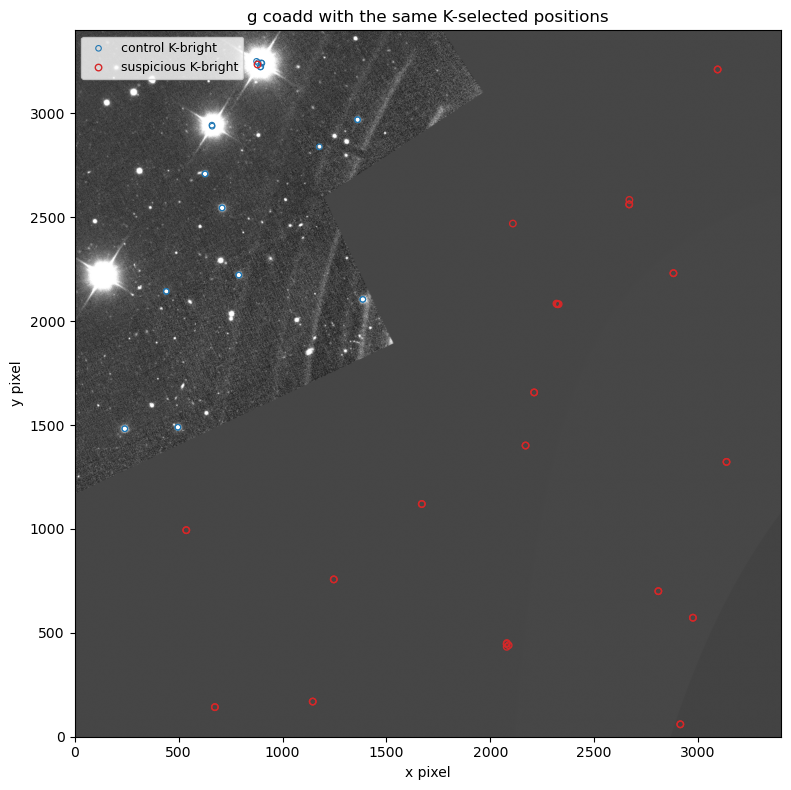

In [11]:
def image_array(exp):
    return np.asarray(exp.image.array, dtype=float)


def show_image_with_overlay(exp, x, y, mask_susp, mask_ctrl, title, filename=None, max_points=2000):
    img = image_array(exp)
    finite = np.isfinite(img)

    if finite.sum() == 0:
        raise RuntimeError("Image has no finite pixels.")

    vmin, vmax = np.nanpercentile(img[finite], [1, 99.5])

    plt.figure(figsize=(8, 8))
    plt.imshow(img, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)

    ctrl_idx = np.where(mask_ctrl & np.isfinite(x) & np.isfinite(y))[0]
    susp_idx = np.where(mask_susp & np.isfinite(x) & np.isfinite(y))[0]

    if len(ctrl_idx) > max_points:
        rng = np.random.default_rng(123)
        ctrl_idx = rng.choice(ctrl_idx, size=max_points, replace=False)

    plt.scatter(
        x[ctrl_idx],
        y[ctrl_idx],
        s=16,
        facecolors="none",
        edgecolors="tab:blue",
        linewidths=0.8,
        label="control K-bright",
    )

    plt.scatter(
        x[susp_idx],
        y[susp_idx],
        s=22,
        facecolors="none",
        edgecolors="tab:red",
        linewidths=1.0,
        label="suspicious K-bright",
    )

    plt.xlim(0, img.shape[1])
    plt.ylim(0, img.shape[0])
    plt.xlabel("x pixel")
    plt.ylabel("y pixel")
    plt.title(title)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()

    if filename is not None:
        savefig(filename)

    plt.show()


show_image_with_overlay(
    K_exp,
    xK,
    yK,
    suspicious,
    control,
    "K coadd with K-bright forced-source overlays",
    filename=f"tract{TRACT}_patch{PATCH}_K_overlay_suspicious_control.png",
)

show_image_with_overlay(
    g_exp,
    xg,
    yg,
    suspicious,
    control,
    "g coadd with the same K-selected positions",
    filename=f"tract{TRACT}_patch{PATCH}_g_overlay_suspicious_control.png",
)

### 13. Cutout helper functions

Each cutout uses the same sky position in both bands. The red cross marks the forced-photometry position.

In [12]:
def get_cutout(img, x, y, half_size=40):
    ny, nx = img.shape
    xc = int(np.round(x))
    yc = int(np.round(y))

    x0 = max(0, xc - half_size)
    x1 = min(nx, xc + half_size + 1)
    y0 = max(0, yc - half_size)
    y1 = min(ny, yc + half_size + 1)

    cut = img[y0:y1, x0:x1]
    return cut, x0, y0


def show_pair_cutout(row, half_size=40, save=False):
    r = src.loc[row]
    imgK = image_array(K_exp)
    imgg = image_array(g_exp)

    cutK, x0K, y0K = get_cutout(imgK, r.xK, r.yK, half_size=half_size)
    cutg, x0g, y0g = get_cutout(imgg, r.xg, r.yg, half_size=half_size)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    for ax, cut, xcen, ycen, x0, y0, title in [
        (axes[0], cutK, r.xK, r.yK, x0K, y0K, "K"),
        (axes[1], cutg, r.xg, r.yg, x0g, y0g, "g"),
    ]:
        finite = np.isfinite(cut)
        if finite.sum() > 0:
            vmin, vmax = np.nanpercentile(cut[finite], [1, 99.5])
        else:
            vmin, vmax = 0, 1

        ax.imshow(cut, origin="lower", cmap="gray", vmin=vmin, vmax=vmax)
        ax.scatter([xcen - x0], [ycen - y0], s=80, marker="+", color="red", linewidths=1.4)
        ax.set_title(title)
        ax.set_xticks([])
        ax.set_yticks([])

    fig.suptitle(
        f"row={int(r.k_row)}  id={int(r.source_id)}  "
        f"K={r.K_mag:.2f}  g={r.g_mag:.2f}  "
        f"g_flag={bool(r.g_flag)}  RA={r.ra_deg:.6f} Dec={r.dec_deg:.6f}",
        fontsize=10,
    )

    plt.tight_layout()

    if save:
        savefig(f"tract{TRACT}_patch{PATCH}_cutout_row{int(r.k_row)}.png")

    plt.show()


def show_many_cutouts(indices, nmax=12, half_size=40):
    for row in list(indices)[:nmax]:
        show_pair_cutout(row, half_size=half_size)

### 14. By-eye inspection of representative suspicious and control sources

Only a small number of cutouts are shown by default to keep the notebook clean. The red cross marks the same forced-photometry position in both bands. Increase `N_CUTOUTS` only for interactive debugging.

Brightest suspicious sources


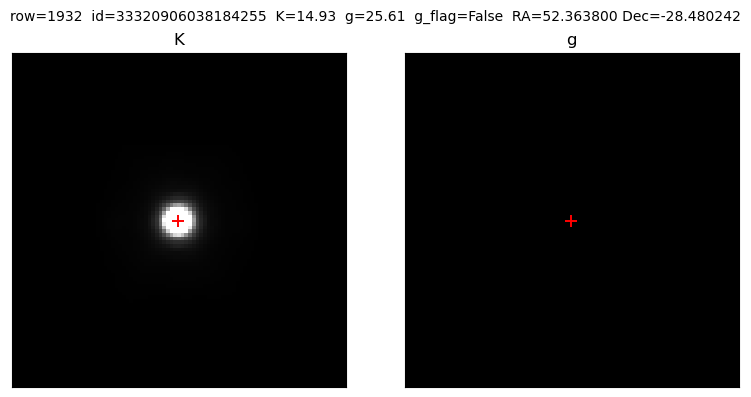

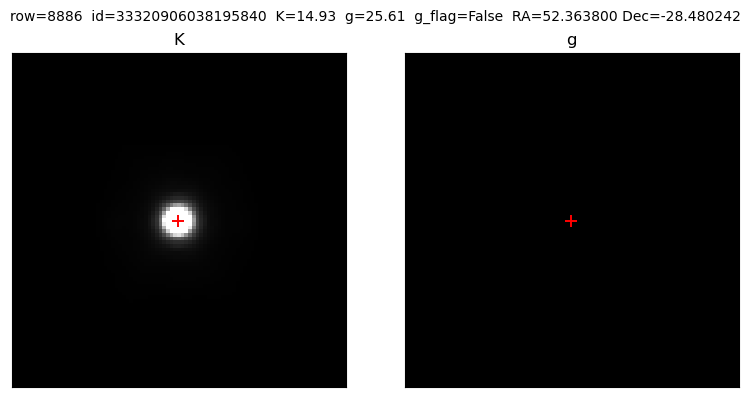

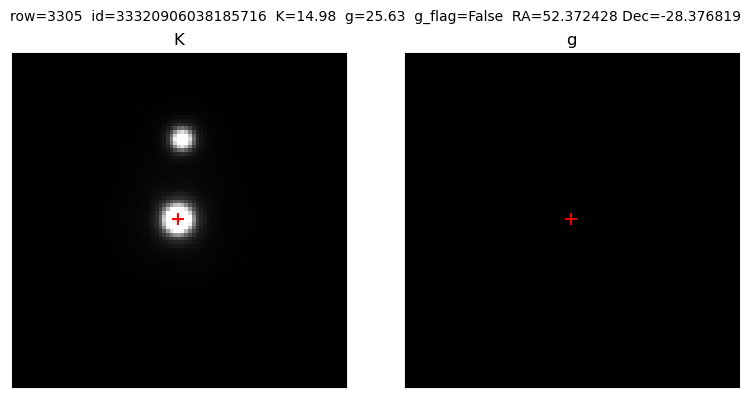

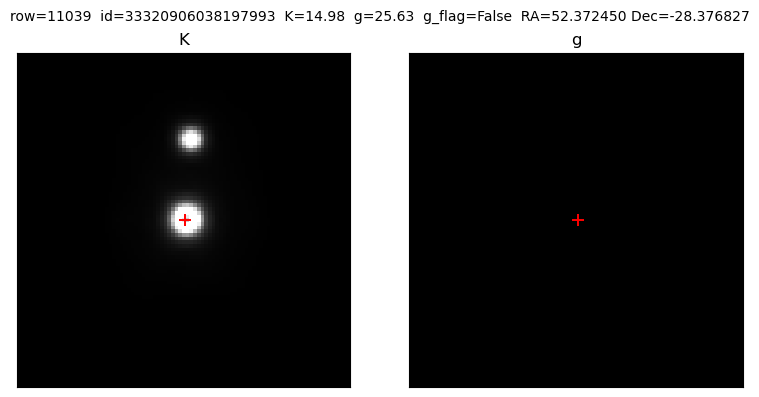

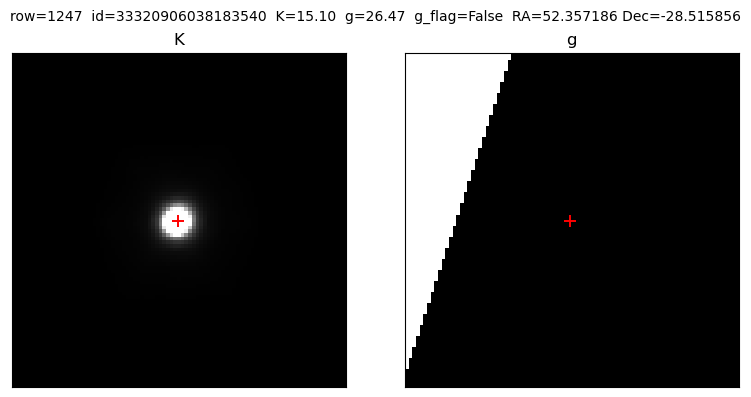

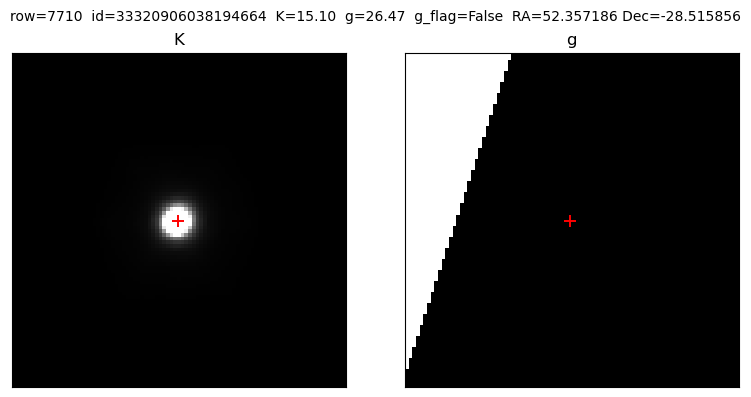


Brightest control sources


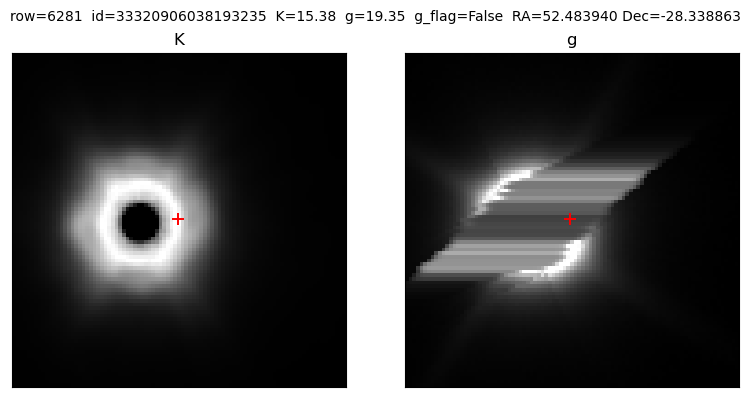

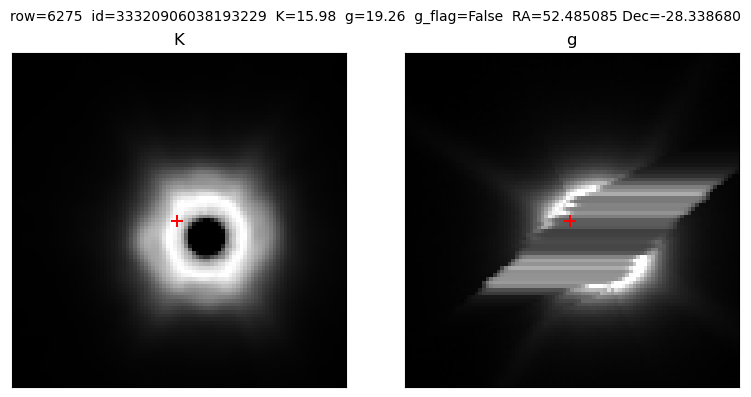

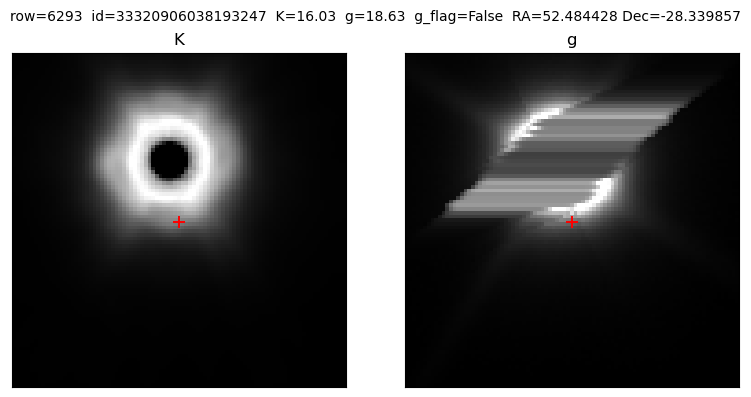

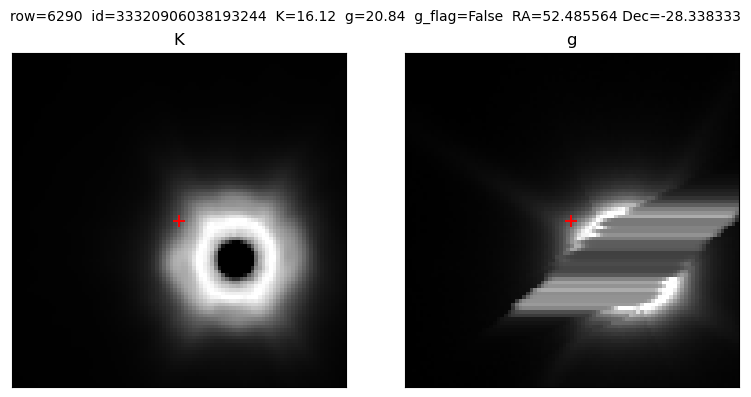

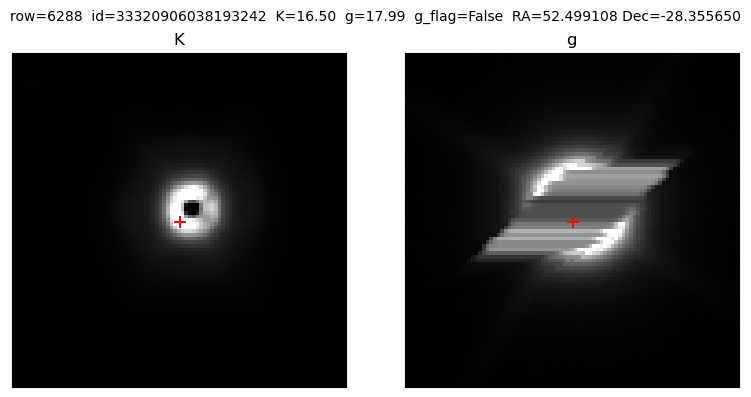

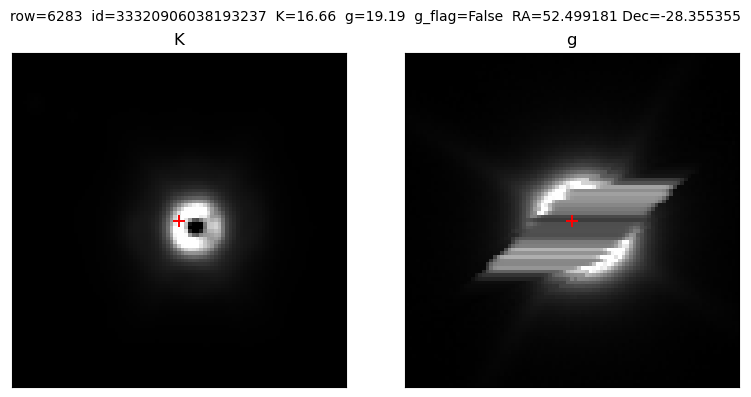

In [13]:
N_CUTOUTS = 6

print("Brightest suspicious sources")
susp_rows_brightest = src.loc[suspicious].sort_values("K_mag").index
show_many_cutouts(susp_rows_brightest, nmax=N_CUTOUTS, half_size=45)

print("\nBrightest control sources")
control_rows = src.loc[control].sort_values("K_mag").index
show_many_cutouts(control_rows, nmax=N_CUTOUTS, half_size=45)


### 15. Check g-band mask planes at K-source positions

This is the main coverage test. The `K` catalogue positions are projected onto the `g` coadd, and the `g` mask value is read at each position. Positions outside the `g` image or on bad mask planes are treated as bad or missing `g` coverage.

In [14]:
def mask_value_at_positions(exp, x, y):
    mask = exp.mask
    bbox = exp.getBBox()

    values = np.zeros(len(x), dtype=np.int64)
    inside = np.zeros(len(x), dtype=bool)

    for ii, (xx, yy) in enumerate(zip(x, y)):
        if not np.isfinite(xx) or not np.isfinite(yy):
            continue

        pix = geom.Point2I(int(np.round(xx + bbox.getMinX())), int(np.round(yy + bbox.getMinY())))

        if bbox.contains(pix):
            inside[ii] = True
            values[ii] = int(mask[pix])

    return values, inside


def has_mask_plane(mask_values, exp, plane_name):
    planes = exp.mask.getMaskPlaneDict()

    if plane_name not in planes:
        return np.zeros(len(mask_values), dtype=bool)

    bit = planes[plane_name]
    return (mask_values & (1 << bit)) != 0


g_mask_values, in_g_bbox = mask_value_at_positions(g_exp, xg, yg)

print("g mask planes:")
print(g_exp.mask.getMaskPlaneDict())

bad_plane_names = [
    "NO_DATA",
    "EDGE",
    "BAD",
    "SAT",
    "SATURATED",
    "CR",
    "INTRP",
    "INTERPOLATED",
    "SUSPECT",
]

bad_g_pixel = ~in_g_bbox

print("\nMask-plane fractions at K-source positions in the g coadd:")
print("outside g bbox:", np.mean(~in_g_bbox))

for plane in bad_plane_names:
    flag = has_mask_plane(g_mask_values, g_exp, plane)
    if np.any(flag):
        print(f"{plane:12s}: {np.mean(flag):.4f}")
    bad_g_pixel |= flag

print("\nFraction of K catalogue positions with bad/no g pixel:")
print(np.mean(bad_g_pixel))

g mask planes:
{'BAD': 0, 'CLIPPED': 11, 'CR': 3, 'CROSSTALK': 17, 'DETECTED': 5, 'DETECTED_NEGATIVE': 6, 'EDGE': 4, 'INEXACT_PSF': 12, 'INTRP': 2, 'ITL_DIP': 18, 'NOT_DEBLENDED': 13, 'NO_DATA': 8, 'REJECTED': 14, 'SAT': 1, 'SENSOR_EDGE': 15, 'STREAK': 10, 'SUSPECT': 7, 'UNMASKEDNAN': 16, 'VIGNETTED': 9}

Mask-plane fractions at K-source positions in the g coadd:
outside g bbox: 0.0
NO_DATA     : 0.7243
EDGE        : 0.0087
SAT         : 0.0003
INTRP       : 0.7243

Fraction of K catalogue positions with bad/no g pixel:
0.7274843474072885


### 16. Connect bright-K / faint-g sources to bad g coverage

This cell checks whether the suspicious bright `K` / faint-`g` sources are preferentially located on bad or missing `g` pixels. This is the key test for distinguishing invalid optical forced measurements from true cross-band mismatches.

N K < 18.0 in target patch: 101
N K-bright with bad/no g coverage: 74
N K-bright with good g coverage: 27

Among K < 18.0 and g > 24.0:
N: 53
fraction with bad/no g coverage: 1.0

Median values:
bad/no g coverage: median g = 25.627672509096264
bad/no g coverage: median K = 16.195714469106534
good g coverage:   median g = 17.267010185444754
good g coverage:   median K = 17.45846933062938


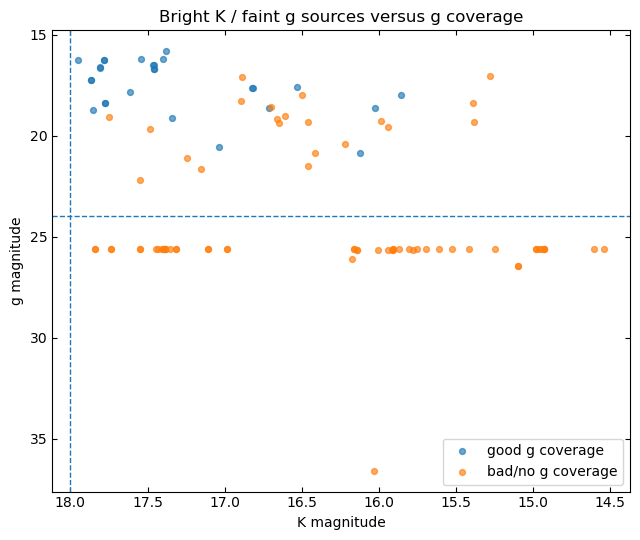

In [15]:
m_Kbright = np.isfinite(K_mag_patch) & (K_mag_patch < K_BRIGHT_LIM)

m_Kbright_g_faint = (
    m_Kbright
    & np.isfinite(g_mag_on_K)
    & (g_mag_on_K > G_FAINT_LIM)
)

m_Kbright_bad_g = m_Kbright & bad_g_pixel
m_Kbright_good_g = m_Kbright & (~bad_g_pixel)

print(f"N K < {K_BRIGHT_LIM} in target patch:", int(m_Kbright.sum()))
print("N K-bright with bad/no g coverage:", int(m_Kbright_bad_g.sum()))
print("N K-bright with good g coverage:", int(m_Kbright_good_g.sum()))

print(f"\nAmong K < {K_BRIGHT_LIM} and g > {G_FAINT_LIM}:")
print("N:", int(m_Kbright_g_faint.sum()))
print(
    "fraction with bad/no g coverage:",
    np.mean(bad_g_pixel[m_Kbright_g_faint]) if m_Kbright_g_faint.sum() > 0 else np.nan,
)

print("\nMedian values:")
print("bad/no g coverage: median g =", np.nanmedian(g_mag_on_K[m_Kbright_bad_g]) if m_Kbright_bad_g.sum() else np.nan)
print("bad/no g coverage: median K =", np.nanmedian(K_mag_patch[m_Kbright_bad_g]) if m_Kbright_bad_g.sum() else np.nan)
print("good g coverage:   median g =", np.nanmedian(g_mag_on_K[m_Kbright_good_g]) if m_Kbright_good_g.sum() else np.nan)
print("good g coverage:   median K =", np.nanmedian(K_mag_patch[m_Kbright_good_g]) if m_Kbright_good_g.sum() else np.nan)

plt.figure(figsize=(6.5, 5.5))
plt.scatter(
    K_mag_patch[m_Kbright_good_g],
    g_mag_on_K[m_Kbright_good_g],
    s=18,
    alpha=0.65,
    label="good g coverage",
)
plt.scatter(
    K_mag_patch[m_Kbright_bad_g],
    g_mag_on_K[m_Kbright_bad_g],
    s=18,
    alpha=0.65,
    label="bad/no g coverage",
)
plt.axhline(G_FAINT_LIM, lw=1, ls="--")
plt.axvline(K_BRIGHT_LIM, lw=1, ls="--")
plt.xlabel("K magnitude")
plt.ylabel("g magnitude")
plt.title("Bright K / faint g sources versus g coverage")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend()
plt.gca().tick_params(direction="in", top=True, right=True)
plt.tight_layout()
savefig(f"tract{TRACT}_patch{PATCH}_brightK_faintg_vs_g_coverage.png")
plt.show()

### 17. Demonstration of a per-band usability flag

This is only a patch-level demonstration. A full production catalogue should use full-coverage per-band columns, but the logic is the same: a band is usable only if the local coverage is valid and the band-specific flux measurement passes the usual finite/error/flag tests.

In [16]:
g_has_valid_coverage_patch = ~bad_g_pixel

g_flux_usable_patch = (
    g_has_valid_coverage_patch
    & matched_by_id
    & np.isfinite(g_mag_on_K)
    & np.isfinite(g_magerr_on_K)
    & (g_magerr_on_K > 0)
    & (g_magerr_on_K < MAGERR_5SIG)
    & (~g_flag_on_K)
)

print("Target patch:")
print("  fraction with valid g coverage:", np.mean(g_has_valid_coverage_patch))
print("  fraction with usable g flux:", np.mean(g_flux_usable_patch))

src["g_has_valid_coverage"] = g_has_valid_coverage_patch
src["g_flux_usable"] = g_flux_usable_patch

coverage_csv = OUTDIR / f"tract{TRACT}_patch{PATCH}_Kg_coverage_flags.csv"
src.to_csv(coverage_csv, index=False)

print("Saved:", coverage_csv)

Target patch:
  fraction with valid g coverage: 0.2725156525927115
  fraction with usable g flux: 0.06156686466527533
Saved: data/plots_photometry/tract4848_patch83_Kg_coverage_flags.csv


### 18. Final interpretation

This notebook explains why the main photometry notebook uses per-band quality masks.

The colour-colour vertical-line problem first appeared as artificial structures in diagrams involving optical colours. The catalogue-level checks showed that these structures were linked to unreliable optical forced measurements, especially flagged or repeated values in individual bands. The image-level checks in this complementary notebook then show why such measurements can occur: a real `K` source can have a forced `g` measurement at a position where the `g` coadd has no valid local coverage or has problematic mask planes.

The important result is that the source itself should not be rejected globally just because one band is unreliable. For example, a source can be valid for `K`-band number counts or near-infrared residual tests, but invalid for a `g-K` colour if the `g` measurement is not usable.

Therefore, the final photometry notebook should continue to use band-specific quality masks. For every residual plot, histogram, or colour-colour diagram, only the bands entering that diagnostic should be required to pass the relevant finite/error/flag/coverage criteria.